### 1.3.1.1. Limit of a Function

$$
\lim_{x \to a} f(x) = L
$$

**Explanation:**

The limit of $f$ as $x$ approaches $a$ is the single real number $L$ that the values $f(x)$ get closer to, and stay close to, as $x$ gets closer to $a$ from either side (with $x \neq a$). The function need not be defined at $a$, and even when it is, the limit and the value $f(a)$ may differ — the limit describes only the *approach*. This idea of an approached value is the foundation on which the [derivative](../02_Single_Variable_Differentiation/01_derivative_definition.ipynb) (a limit of slopes) and the [definite integral](../03_Single_Variable_Integration/02_definite_integral_and_riemann_sums.ipynb) (a limit of sums) are built.

**Intuition:**

A limit can be estimated from a table of functional values: pick $x$-values approaching $a$ from below and from above. If both columns of $f(x)$ approach a common number $L$, that number is the limit.

**Numerical Example:**

Consider $f(x) = \dfrac{\sin x}{x}$ near $x = 0$. The value $f(0)$ is undefined (it is the indeterminate form $0/0$), yet the limit exists. Tabulating $f$ from both sides (with $x$ in radians):

$$
\begin{array}{c|c}
x & \sin(x)/x \\ \hline
\pm 0.1 & 0.998334\ldots \\
\pm 0.01 & 0.999983\ldots \\
\pm 0.001 & 0.999999\ldots
\end{array}
$$

As $x \to 0$ from the left and from the right, the values increase toward the same number $1$. Therefore

$$
\lim_{x \to 0} \frac{\sin x}{x} = 1,
$$

even though $f$ is not defined at $x = 0$.

In [1]:
import sympy as sp

x = sp.symbols("x")
f = sp.sin(x) / x

approaching_values = [sp.Rational(1, 10**power) for power in range(1, 4)]
table = [(point, sp.N(f.subs(x, point), 12)) for point in approaching_values]

limit_value = sp.limit(f, x, 0)

for point, value in table:
    print(f"f(±{float(point):>7}) = {value}")
print("lim_{x->0} sin(x)/x =", limit_value)

f(±    0.1) = 0.998334166468
f(±   0.01) = 0.999983333417
f(±  0.001) = 0.999999833333
lim_{x->0} sin(x)/x = 1


**Equivalent numerical (NumPy) table:**

The symbolic limit can be cross-checked by sampling $f$ on points that march toward $0$ — the same table-of-values method, evaluated in floating point.

In [2]:
import numpy as np

offsets = np.array([1e-1, 1e-2, 1e-3, 1e-4])
left_values = np.sin(-offsets) / (-offsets)
right_values = np.sin(offsets) / offsets

for offset, left, right in zip(offsets, left_values, right_values):
    print(f"x=±{offset:>7}:  f(-)={left:.12f}  f(+)={right:.12f}")

x=±    0.1:  f(-)=0.998334166468  f(+)=0.998334166468
x=±   0.01:  f(-)=0.999983333417  f(+)=0.999983333417
x=±  0.001:  f(-)=0.999999833333  f(+)=0.999999833333
x=± 0.0001:  f(-)=0.999999998333  f(+)=0.999999998333


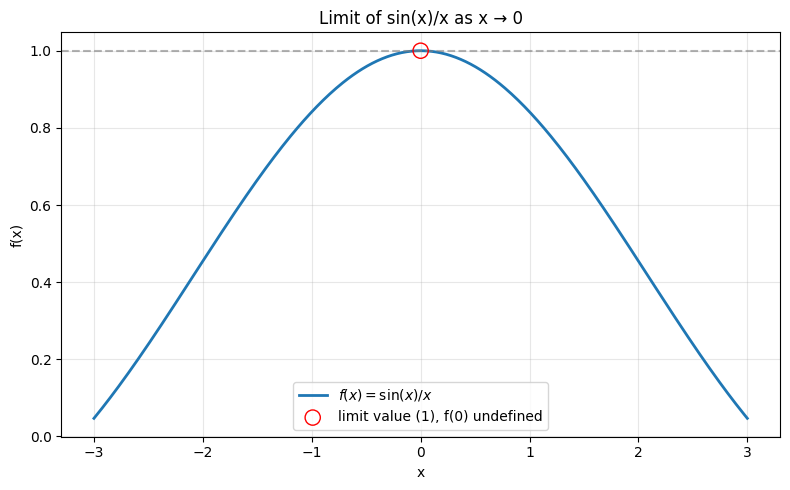

In [3]:
import numpy as np
import matplotlib.pyplot as plt

sample_points = np.linspace(-3, 3, 400)
sample_points = sample_points[np.abs(sample_points) > 1e-6]
sample_values = np.sin(sample_points) / sample_points

plt.figure(figsize=(8, 5))
plt.plot(sample_points, sample_values, linewidth=2, label=r"$f(x)=\sin(x)/x$")
plt.scatter([0], [1], facecolors="none", edgecolors="red", s=120, zorder=5, label="limit value (1), f(0) undefined")
plt.axhline(1, color="gray", linestyle="--", alpha=0.6)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Limit of sin(x)/x as x → 0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The precise ($\varepsilon$–$\delta$) definition:**

The intuitive statement is made rigorous as follows: $\lim_{x \to a} f(x) = L$ means that for every $\varepsilon > 0$ there exists a $\delta > 0$ such that

$$
0 < |x - a| < \delta \;\Rightarrow\; |f(x) - L| < \varepsilon.
$$

In words, $f(x)$ can be forced within any tolerance $\varepsilon$ of $L$ by restricting $x$ to a small enough punctured neighbourhood of $a$. This formulation is what underlies convergence arguments used later for sequences and optimization methods.

**References:**

[📘 Strang, G. (2016). *Calculus Volume 1*. OpenStax.](https://openstax.org/details/books/calculus-volume-1)

---

[⬅️ Previous: Vectors and One-Forms](../../01_Linear_Algebra/09_Multilinear_Algebra_and_Tensors/13_vectors_and_one_forms.ipynb) | [Next: Limit Laws ➡️](./02_limit_laws.ipynb)